In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import zipfile
from collections import Counter

import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

import pandas as pd
import numpy as np
import cv2
from PIL import Image
from tqdm import tqdm

from sklearn.metrics import (
    f1_score, confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


In [3]:
zip_path = '/content/drive/MyDrive/Projects/ML_Project/DAiSEE.zip'
extract_path = '/content/DAiSEE'

if not os.path.exists(extract_path):
    print('Extracting dataset...')
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print('Done!')
else:
    print('Dataset already extracted.')

Extracting dataset...
Done!


In [4]:
train_df = pd.read_csv('/content/DAiSEE/DAiSEE/Labels/TrainLabels.csv')
val_df   = pd.read_csv('/content/DAiSEE/DAiSEE/Labels/ValidationLabels.csv')
test_df  = pd.read_csv('/content/DAiSEE/DAiSEE/Labels/TestLabels.csv')

for df in [train_df, val_df, test_df]:
    df.columns = df.columns.str.strip()
    df['label'] = (df['Engagement'] >= 2).astype(int)

print('Label distribution:')
print('Train:     ', dict(train_df['label'].value_counts().sort_index()))
print('Validation:', dict(val_df['label'].value_counts().sort_index()))
print('Test:      ', dict(test_df['label'].value_counts().sort_index()))

Label distribution:
Train:      {0: np.int64(247), 1: np.int64(5111)}
Validation: {0: np.int64(166), 1: np.int64(1263)}
Test:       {0: np.int64(88), 1: np.int64(1696)}


In [5]:
def extract_frames(video_path, output_folder, fps=1):
    os.makedirs(output_folder, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    video_fps = cap.get(cv2.CAP_PROP_FPS)
    interval = max(1, int(video_fps / fps))
    frame_count, saved_count = 0, 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if frame_count % interval == 0:
            cv2.imwrite(f'{output_folder}/frame_{saved_count:04d}.jpg', frame)
            saved_count += 1
        frame_count += 1
    cap.release()
    return saved_count

def process_split(df, split_name, data_root):
    print(f'Processing {split_name}...')
    missing = 0
    for _, row in tqdm(df.iterrows(), total=len(df)):
        clip_id   = row['ClipID']
        label     = row['label']
        clip_name = clip_id.replace('.avi', '')
        person_id = clip_name[:6]
        video_path  = f'{data_root}/DAiSEE/DataSet/{split_name}/{person_id}/{clip_name}/{clip_id}'
        output_path = f'/content/frames/{split_name}/{label}/{clip_name}'
        if os.path.exists(video_path):
            extract_frames(video_path, output_path)
        else:
            missing += 1
    print(f'Done. Missing videos: {missing}')

if not os.path.exists('/content/frames'):
    data_root = '/content/DAiSEE'
    process_split(train_df, 'Train',      data_root)
    process_split(val_df,   'Validation', data_root)
    process_split(test_df,  'Test',       data_root)
else:
    print('Frames already extracted.')

for split in ['Train', 'Validation', 'Test']:
    for label in ['0', '1']:
        path = f'/content/frames/{split}/{label}'
        if os.path.exists(path):
            count = sum(len(files) for _, _, files in os.walk(path))
            print(f'{split} | label={label} | {count} frames')

Processing Train...


100%|██████████| 5358/5358 [19:30<00:00,  4.58it/s]


Done. Missing videos: 506
Processing Validation...


100%|██████████| 1429/1429 [05:41<00:00,  4.18it/s]


Done. Missing videos: 0
Processing Test...


100%|██████████| 1784/1784 [06:20<00:00,  4.69it/s]


Done. Missing videos: 146
Train | label=0 | 2340 frames
Train | label=1 | 46180 frames
Validation | label=0 | 1660 frames
Validation | label=1 | 12630 frames
Test | label=0 | 850 frames
Test | label=1 | 15530 frames


In [6]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class EngagementDataset(Dataset):
    def __init__(self, frames_dir, transform=None):
        self.transform = transform
        self.samples = []
        for label in ['0', '1']:
            label_dir = os.path.join(frames_dir, label)
            if not os.path.exists(label_dir):
                continue
            for clip_folder in os.listdir(label_dir):
                clip_path = os.path.join(label_dir, clip_folder)
                for frame_file in os.listdir(clip_path):
                    if frame_file.endswith('.jpg'):
                        self.samples.append((
                            os.path.join(clip_path, frame_file),
                            int(label)
                        ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

train_dataset = EngagementDataset('/content/frames/Train',      transform=train_transforms)
val_dataset   = EngagementDataset('/content/frames/Validation', transform=val_test_transforms)
test_dataset  = EngagementDataset('/content/frames/Test',       transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

print(f'Train samples:      {len(train_dataset)}')
print(f'Validation samples: {len(val_dataset)}')
print(f'Test samples:       {len(test_dataset)}')

Train samples:      48520
Validation samples: 14290
Test samples:       16380


In [8]:
SAVE_PATH = '/content/drive/MyDrive/Projects/ML_Project/vgg16_best.pth'

# Calculate class weights dynamically
total          = len(train_dataset)
n_not_engaged  = sum(1 for _, l in train_dataset.samples if l == 0)
n_engaged      = sum(1 for _, l in train_dataset.samples if l == 1)
weight_not_engaged = total / (2 * n_not_engaged)
weight_engaged     = total / (2 * n_engaged)
class_weights = torch.tensor([weight_not_engaged, weight_engaged]).to(device)
print(f'Class weights — Not Engaged: {weight_not_engaged:.2f}, Engaged: {weight_engaged:.2f}')

# Load VGG-16 pretrained on ImageNet
model = models.vgg16(weights='IMAGENET1K_V1')

# Freeze all, then unfreeze last conv block + classifier
for param in model.parameters():
    param.requires_grad = False
for param in model.features[24:].parameters():
    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True

model.classifier[6] = nn.Linear(4096, 2)
model = model.to(device)

optimizer = torch.optim.Adam([
    {'params': model.features[24:].parameters(), 'lr': 1e-5},
    {'params': model.classifier.parameters(),    'lr': 1e-4}
])
criterion = nn.CrossEntropyLoss(weight=class_weights)
scheduler = ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5)

print('Model ready.')

Class weights — Not Engaged: 10.37, Engaged: 0.53
Model ready.


In [9]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=15):
    best_val_f1 = 0
    history = {'train_loss': [], 'val_f1': []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_f1   = f1_score(all_labels, all_preds, average='macro')
        avg_loss = train_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        history['val_f1'].append(val_f1)

        print(f'Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Val F1: {val_f1:.4f}')
        scheduler.step(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), SAVE_PATH)
            print(f'  ✅ New best model saved! (F1: {val_f1:.4f})')

    print(f'\nTraining complete! Best Val F1: {best_val_f1:.4f}')
    return history

history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=15)

Epoch 1/15 | Loss: 0.6150 | Val F1: 0.4989
  ✅ New best model saved! (F1: 0.4989)
Epoch 2/15 | Loss: 0.4726 | Val F1: 0.5407
  ✅ New best model saved! (F1: 0.5407)
Epoch 3/15 | Loss: 0.3856 | Val F1: 0.5395
Epoch 4/15 | Loss: 0.3211 | Val F1: 0.5391
Epoch 5/15 | Loss: 0.3025 | Val F1: 0.5182
Epoch 6/15 | Loss: 0.2404 | Val F1: 0.5221
Epoch 7/15 | Loss: 0.2128 | Val F1: 0.5310
Epoch 8/15 | Loss: 0.2038 | Val F1: 0.5136
Epoch 9/15 | Loss: 0.1741 | Val F1: 0.5223
Epoch 10/15 | Loss: 0.1623 | Val F1: 0.5082
Epoch 11/15 | Loss: 0.1569 | Val F1: 0.5137
Epoch 12/15 | Loss: 0.1384 | Val F1: 0.5167
Epoch 13/15 | Loss: 0.1349 | Val F1: 0.5110
Epoch 14/15 | Loss: 0.1287 | Val F1: 0.5110
Epoch 15/15 | Loss: 0.1266 | Val F1: 0.5070

Training complete! Best Val F1: 0.5407


In [10]:
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1)[:, 1]
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print('=== Test Set Results ===')
print(classification_report(all_labels, all_preds, target_names=['Not Engaged', 'Engaged']))

=== Test Set Results ===
              precision    recall  f1-score   support

 Not Engaged       0.05      0.20      0.08       850
     Engaged       0.95      0.80      0.87     15530

    accuracy                           0.76     16380
   macro avg       0.50      0.50      0.47     16380
weighted avg       0.90      0.76      0.82     16380



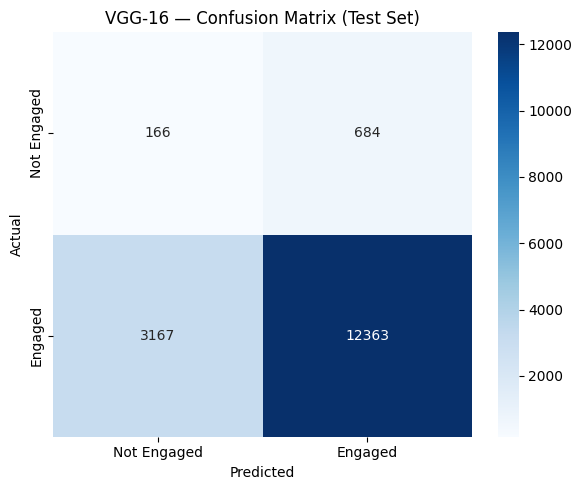

Saved.


In [11]:
PLOTS_DIR = '/content/drive/MyDrive/Projects/ML_Project/results/vgg16/'
os.makedirs(PLOTS_DIR, exist_ok=True)

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Engaged', 'Engaged'],
            yticklabels=['Not Engaged', 'Engaged'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('VGG-16 — Confusion Matrix (Test Set)')
plt.tight_layout()
plt.savefig(PLOTS_DIR + 'confusion_matrix.png', dpi=150)
plt.show()
print('Saved.')

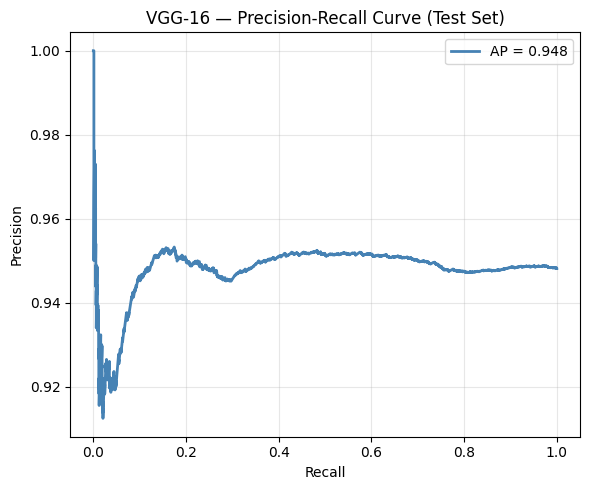

Saved.


In [12]:
precision, recall, _ = precision_recall_curve(all_labels, all_probs)
ap = average_precision_score(all_labels, all_probs)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall, precision, color='steelblue', lw=2, label=f'AP = {ap:.3f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('VGG-16 — Precision-Recall Curve (Test Set)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR + 'pr_curve.png', dpi=150)
plt.show()
print('Saved.')

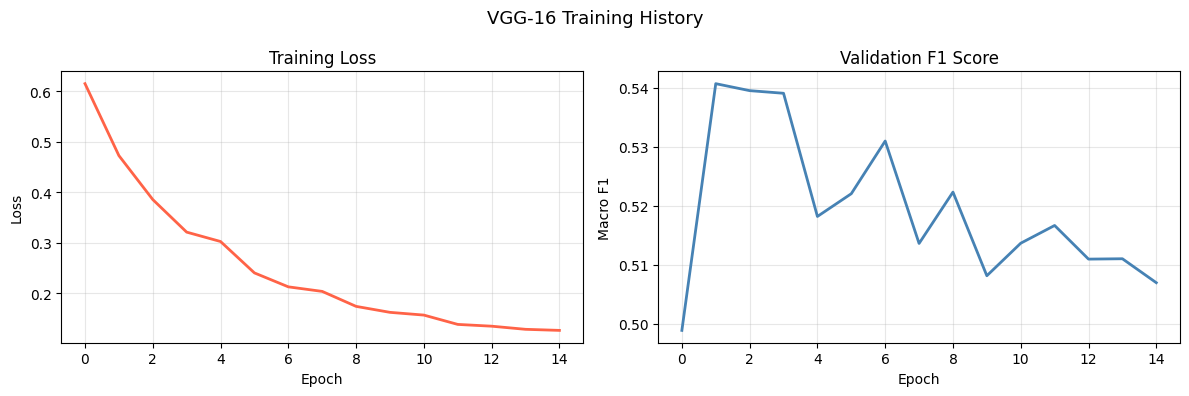

Saved.


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], color='tomato', lw=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(history['val_f1'], color='steelblue', lw=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Macro F1')
ax2.set_title('Validation F1 Score')
ax2.grid(True, alpha=0.3)

plt.suptitle('VGG-16 Training History', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR + 'training_history.png', dpi=150)
plt.show()
print('Saved.')